# TIME FORECASTING MODELS

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
stock_data = yf.download('AAPL',start='2023-01-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.211197,128.954545,122.324571,128.343764,112117500
2023-01-04,124.482025,126.747845,123.221050,125.004147,89113600
2023-01-05,123.161942,125.871071,122.905811,125.240583,80962700
2023-01-06,127.693588,128.353629,123.033890,124.137247,87754700
2023-01-09,128.215698,131.427258,127.959568,128.530950,70790800


In [4]:
apple_price_stationary = stock_data['Close'].diff().dropna() # Used 1st order differencing inorder to make data stationary

# Split the data into training and testing datasets
train_data, test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]

# 1. AR MODEL

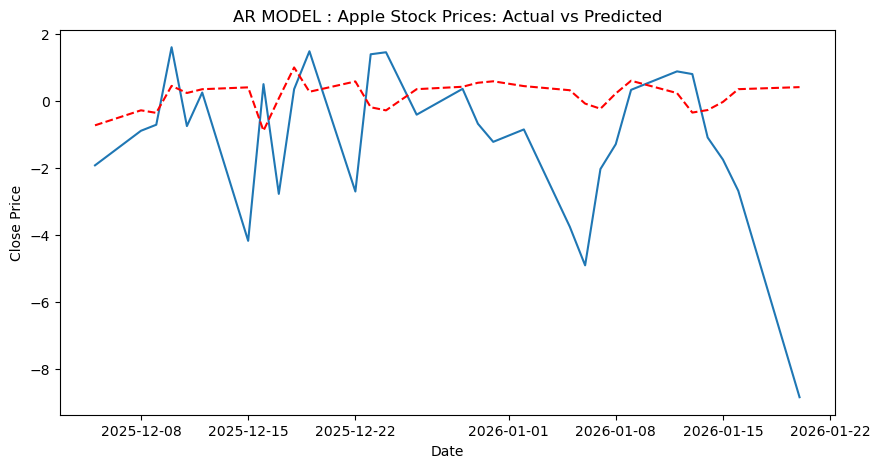

RMSE: 2.62


In [6]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Fit the Autoregressive model (AR) to the training data
model = AutoReg(train_data, lags=30) # lags = 30 days means we take a time span of 30 days to predict value of next 30 days based on prev 30 days
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('AR MODEL : Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE:', rmse)

# 2. MA MODEL

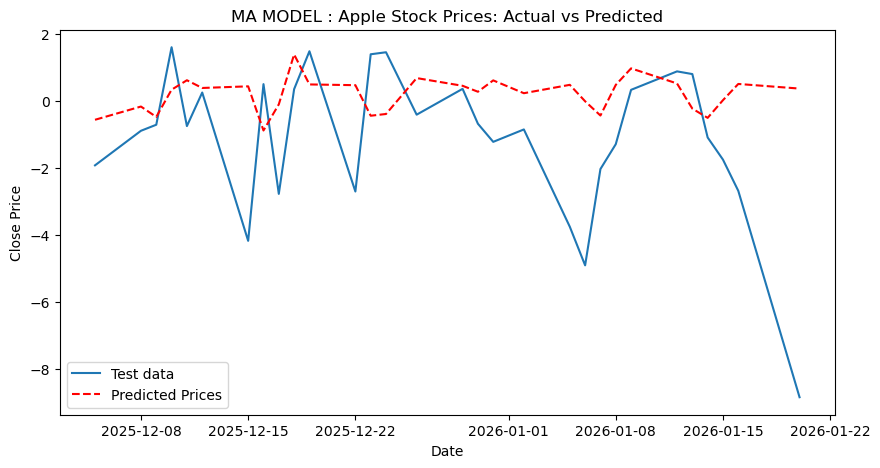

RMSE: 2.64


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the Moving Average (MA) to the training data
model_fit = ARIMA(train_data, order=(0,0,30)).fit() # THE VALUS OF P,D are kept as zero and Q is 30 as it is a MA model

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('MA MODEL : Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE:', rmse)

# 3. ARMA MODEL

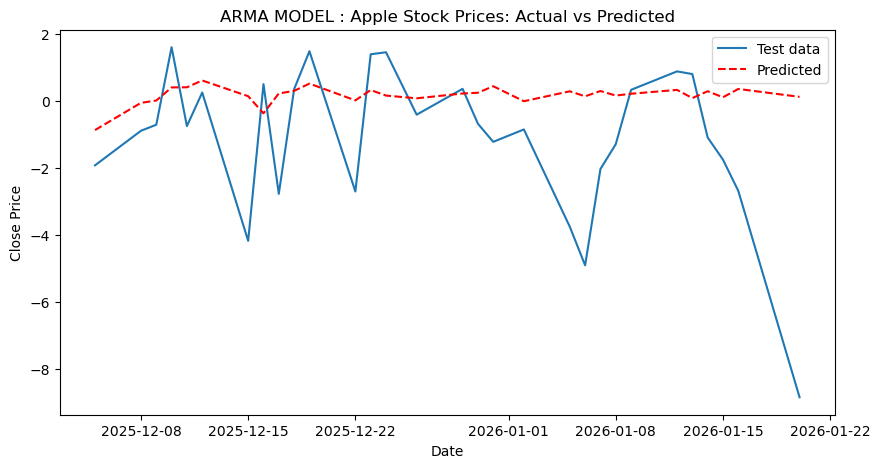

RMSE:  2.54


In [10]:
# Note here order is set based on trail and error method tried to keep the least rmse score 
# but there is also a perfect way to set this order value i.e by using various techniques like ACF,PACF etc we'll we later on
# VALUE OF D IS KEPT 0 AS IT IS ARMA MODEL AND NOT THE ARIMA MODEL WHERE I STANDS FOR THE DIFFERENCING ORDER PART
model = ARIMA(train_data, order=(7,0,7)) 
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data), 
    end=len(train_data) + len(test_data) - 1, 
    dynamic=False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')
plt.title('ARMA MODEL : Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

# 4. ARIMA MODEL

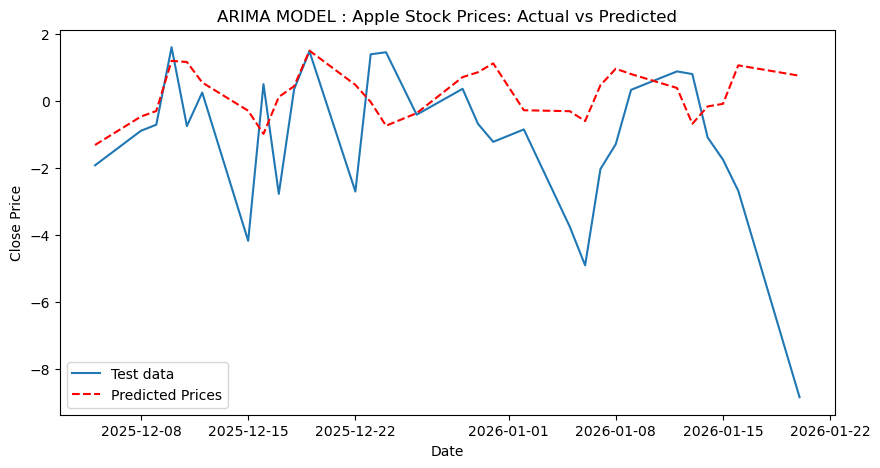

RMSE: 2.64


In [12]:
# Fit the Moving Average (MA) model to the training data
# Here the D is kept 1 as we are using the first order differencing so that we can get a STATIONARY data
model = ARIMA(train_data, order=(7,1,7))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('ARIMA MODEL : Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE:', rmse)

# 5. SARIMA MODEL (SEASONAL ARIMA)

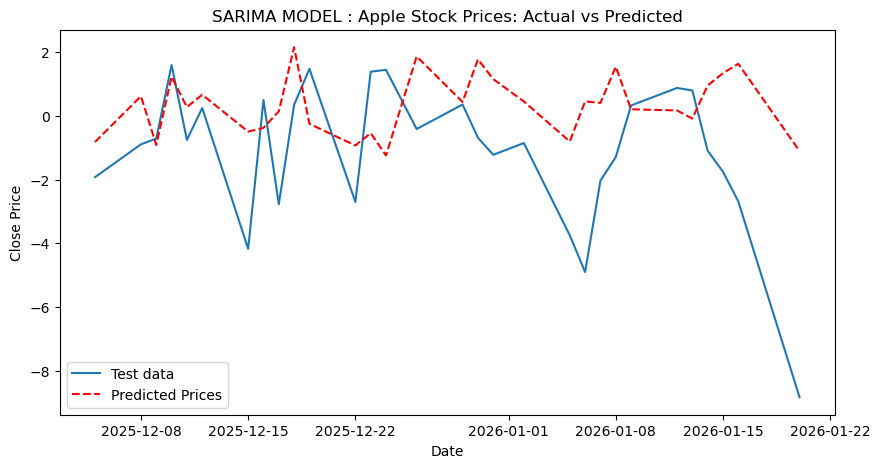

RMSE:  2.66


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p , d , q = 7 , 1 , 7 # chosen by trail and error method
P , D , Q , s = 1 , 1 , 1 , 45 # here s = 45 as we took 45 days period 

# Fit the SARIMA model
model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('SARIMA MODEL : Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

# VECTOR MODELS

In [16]:
tsla_data = yf.download('TSLA', start='2023-01-01')
stock_data['TSLA_Close'] = tsla_data['Close']
stock_data['APPL_Close'] = stock_data['Close'].shift()
stock_data.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

#perform Granger-Causality test
grangercausalitytests(stock_data[['APPL_Close', 'TSLA_Close']].dropna(), maxlag=14)
print()

[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.5884  , p=0.0020  , df_denom=759, df_num=1
ssr based chi2 test:   chi2=9.6263  , p=0.0019  , df=1
likelihood ratio test: chi2=9.5660  , p=0.0020  , df=1
parameter F test:         F=9.5884  , p=0.0020  , df_denom=759, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=73.7687 , p=0.0000  , df_denom=756, df_num=2
ssr based chi2 test:   chi2=148.5132, p=0.0000  , df=2
likelihood ratio test: chi2=135.6681, p=0.0000  , df=2
parameter F test:         F=73.7687 , p=0.0000  , df_denom=756, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=49.2962 , p=0.0000  , df_denom=753, df_num=3
ssr based chi2 test:   chi2=149.2632, p=0.0000  , df=3
likelihood ratio test: chi2=136.2803, p=0.0000  , df=3
parameter F test:         F=49.2962 , p=0.0000  , df_denom=753, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=36.5665 , p=0.0000  

In [17]:
tsla_data.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2023-01-03,108.099998,118.800003,104.639999,118.470001,231402800
2023-01-04,113.639999,114.589996,107.519997,109.110001,180389000
2023-01-05,110.339996,111.750000,107.160004,110.510002,157986300
2023-01-06,113.059998,114.389999,101.809998,103.000000,220911100
2023-01-09,119.769997,123.519997,117.110001,118.959999,190284000


In [18]:
stock_data.head()

Price,Close,High,Low,Open,Volume,TSLA_Close,APPL_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2023-01-04,124.482025,126.747845,123.221050,125.004147,89113600,113.639999,123.211197
2023-01-05,123.161942,125.871071,122.905811,125.240583,80962700,110.339996,124.482025
2023-01-06,127.693588,128.353629,123.033890,124.137247,87754700,113.059998,123.161942
2023-01-09,128.215698,131.427258,127.959568,128.530950,70790800,119.769997,127.693588
2023-01-10,128.787079,129.309201,126.215868,128.324063,63896200,118.849998,128.215698


In [19]:
data = stock_data[['APPL_Close','TSLA_Close']].diff().dropna() # first order diff for making data stationary also after first order diff there will be one NA value to remove it use dropna()

In [20]:
train_data , test_data = data[:-14] , data[-14:]

# 1. VAR MODEL

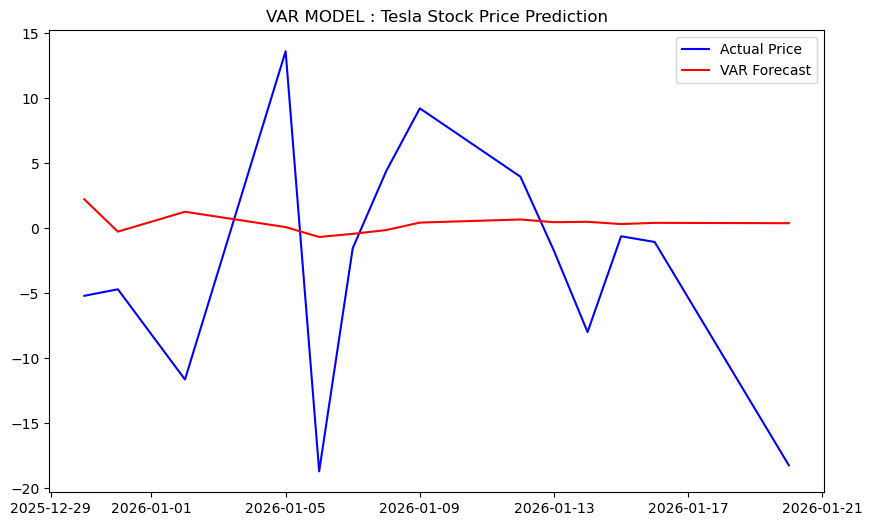

RMSE:  9.58


In [22]:
from statsmodels.tsa.api import VAR, VARMAX

# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)
plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('VAR MODEL : Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

# 2. VMA MODEL

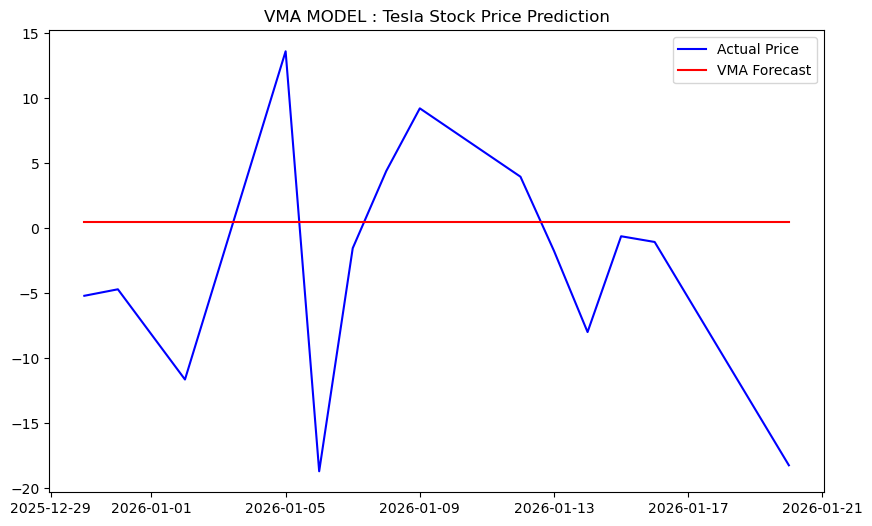

RMSE:  9.58


In [24]:
model = VARMAX(train_data, order=(0,14))
result = model.fit()
predictions = result.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VMA Forecast', color='red')
plt.legend()
plt.title('VMA MODEL : Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])),2)
print('RMSE: ',rmse)

# 3. VARIMA MODEL

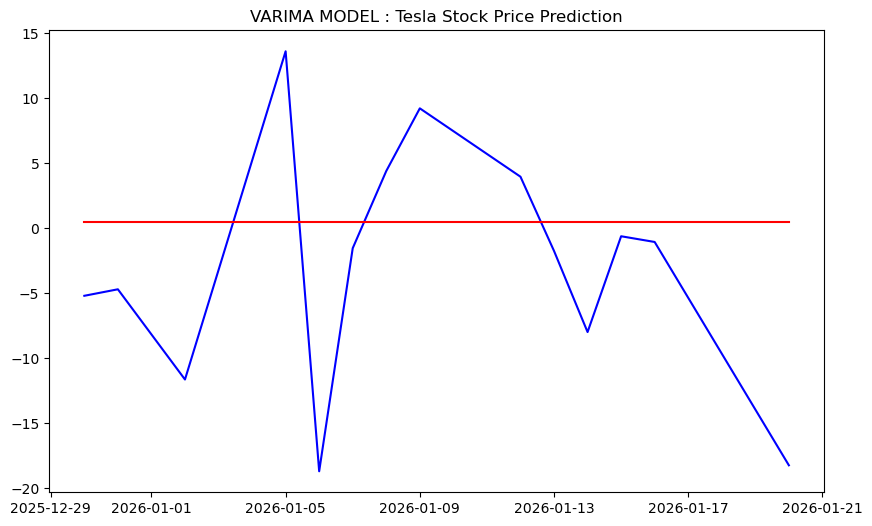

RMSE:  9.58


In [26]:
model = VARMAX(train_data, order=(14,14))
result = model.fit()
predictions = result.predict(start=len(train_data), end=len(train_data) + len(test_data)-1, dynamic=False)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VARIMA Forecast', color='red')
plt.title('VARIMA MODEL : Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])),2)
print('RMSE: ',rmse)

# SMOOTHING METHODS

# 1. MOVING AVERAGE

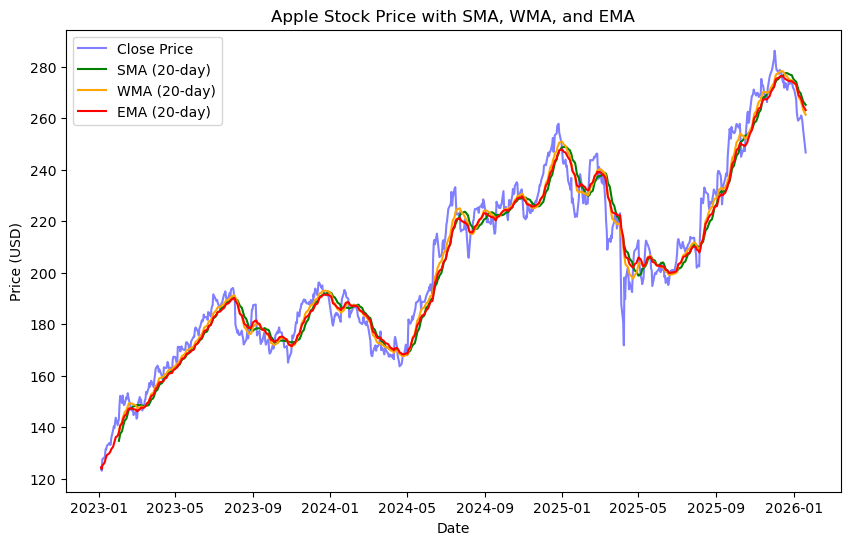

In [46]:
window_size = 20
stock_data['SMA'] = stock_data['Close'].rolling(window=window_size).mean()

# Calculate Weighted Moving Average (WMA)
weights = np.arange(1, window_size + 1)
stock_data['WMA'] = stock_data['Close'].rolling(window_size).apply(lambda prices: np.dot(prices, weights) / weights.sum(), raw=True)

# Calculate Exponential Moving Average (EMA)
stock_data['EMA'] = stock_data['Close'].ewm(span=window_size).mean()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SMA'], label=f'SMA ({window_size}-day)', color='green')
plt.plot(stock_data['WMA'], label=f'WMA ({window_size}-day)', color='orange')
plt.plot(stock_data['EMA'], label=f'EMA ({window_size}-day)', color='red')
plt.title('Apple Stock Price with SMA, WMA, and EMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# 2. EXPONENTIAL SMOOTHING

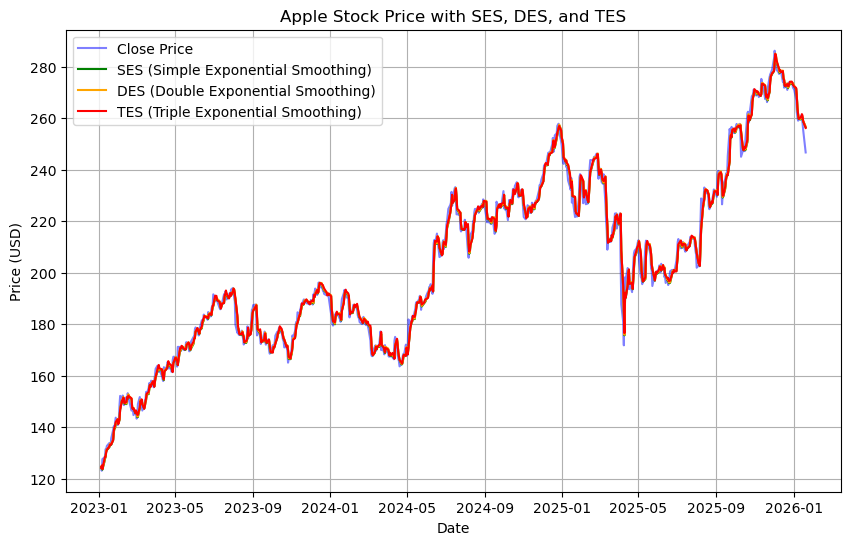

In [49]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

close_prices = stock_data['Close']
ses_model = SimpleExpSmoothing(close_prices).fit(smoothing_level=0.7)
stock_data['SES'] = ses_model.fittedvalues

# Double Exponential Smoothing (DES) - Holt's linear trend model
des_model = ExponentialSmoothing(close_prices, trend='add').fit(smoothing_level=0.7)
stock_data['DES'] = des_model.fittedvalues

# Triple Exponential Smoothing (TES) - Holt-Winters method
tes_model = ExponentialSmoothing(close_prices, trend='add', seasonal='add', seasonal_periods=12).fit(smoothing_level=0.7)
stock_data['TES'] = tes_model.fittedvalues

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SES'], label='SES (Simple Exponential Smoothing)', color='green')
plt.plot(stock_data['DES'], label='DES (Double Exponential Smoothing)', color='orange')
plt.plot(stock_data['TES'], label='TES (Triple Exponential Smoothing)', color='red')
plt.title('Apple Stock Price with SES, DES, and TES')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()